In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.proportion import proportions_ztest

sns.set_style("whitegrid")
df = pd.read_csv("/Users/prerana/Documents/Marketing_Conversion_Analytics/data/marketing_conversion.csv")

df.head()

,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion
0,8000,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,IsConfid,ToolConfid,1
1,8001,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,IsConfid,ToolConfid,1
2,8002,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,IsConfid,ToolConfid,1
3,8003,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,IsConfid,ToolConfid,1
4,8004,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,IsConfid,ToolConfid,1


In [2]:
#Create experiment groups
median_spend = df["AdSpend"].median()

df["ExperimentGroup"] = np.where(
    df["AdSpend"] > median_spend,
    "Treatment",
    "Control"
)

df["ExperimentGroup"].value_counts()

ExperimentGroup
Treatment    4000
Control      4000
Name: count, dtype: int64

In [3]:
#Conversion rate by group
group_conversion = (
    df.groupby("ExperimentGroup")["Conversion"]
      .agg(["count","sum","mean"])
)

group_conversion

group_conversion["ConversionRate"] = (
    group_conversion["mean"] * 100
)

group_conversion

,count,sum,mean,ConversionRate
ExperimentGroup,,,,
Control,4000,3321,0.83025,83.025
Treatment,4000,3691,0.92275,92.275


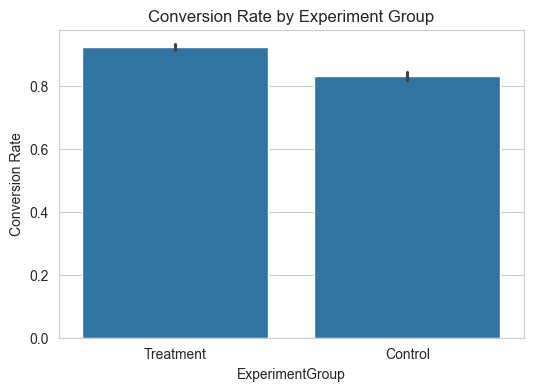

In [4]:
#Visualization
plt.figure(figsize=(6,4))

sns.barplot(
    data=df,
    x="ExperimentGroup",
    y="Conversion"
)

plt.title("Conversion Rate by Experiment Group")
plt.ylabel("Conversion Rate")

plt.show()

In [5]:
#Calculate lift
control_rate = (
    df[df["ExperimentGroup"]=="Control"]
    ["Conversion"]
    .mean()
)

treatment_rate = (
    df[df["ExperimentGroup"]=="Treatment"]
    ["Conversion"]
    .mean()
)

lift = (
    (treatment_rate - control_rate)
    / control_rate
) * 100

print(f"Control Conversion Rate: {control_rate:.4f}")
print(f"Treatment Conversion Rate: {treatment_rate:.4f}")
print(f"Lift: {lift:.2f}%")

Control Conversion Rate: 0.8303
Treatment Conversion Rate: 0.9227
Lift: 11.14%


In [6]:
#Statistical significance test
control = df[df["ExperimentGroup"]=="Control"]

treatment = df[df["ExperimentGroup"]=="Treatment"]

successes = np.array([
    control["Conversion"].sum(),
    treatment["Conversion"].sum()
])

observations = np.array([
    len(control),
    len(treatment)
])

z_stat, p_value = proportions_ztest(
    successes,
    observations
)

print("Z Statistic:", z_stat)
print("P Value:", p_value)

Z Statistic: -12.573242491046676
P Value: 2.9631683208307592e-36


In [7]:
#Decision
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis")
    print("Difference is statistically significant")
else:
    print("Fail to reject the null hypothesis")
    print("Difference is NOT statistically significant")

Reject the null hypothesis
Difference is statistically significant


In [8]:
#Confidence interval
from statsmodels.stats.proportion import confint_proportions_2indep

ci = confint_proportions_2indep(
    count1=treatment["Conversion"].sum(),
    nobs1=len(treatment),
    count2=control["Conversion"].sum(),
    nobs2=len(control),
    method="wald"
)

print(ci)

(np.float64(0.07822393342777577), np.float64(0.10677606657222406))


In [9]:
## A/B Test Results
#Objective:
#Evaluate whether higher advertising spend is associated with higher conversion rates.

#Method:
#Customers were divided into Control and Treatment groups using median Ad Spend.

#Results:
#- Control Conversion Rate: 83%
#- Treatment Conversion Rate: 92%
#- Lift: 11.14%
#- p-value: 2.96

#Conclusion:
#The treatment group demonstrated a statistically significant improvement in conversion performance. 

In [10]:
## Business Recommendation

#As the treatment group's conversion improvement is statistically significant, marketing teams should consider increasing investment in higher-performing campaigns while continuously monitoring ROI.

#Future experiments should utilize randomized control groups to establish causal relationships and optimize marketing spend allocation.